<a href="https://colab.research.google.com/github/HelloJacob11/Double-Moving-Average-Crossover-ML/blob/main/double_moving_average_crossover_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance          # in Colab
import yfinance as yf
import numpy as np
import pandas as pd

In [ ]:
data = yf.download("SPY", start="2005-01-01", auto_adjust=False)
if isinstance(data.columns,pd.MultiIndex):
  data.columns = data.columns.droplevel(1)
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price       Adj Close       Close        High         Low        Open  \
Date                                                                    
2005-01-03  80.973549  120.300003  121.760002  119.900002  121.559998   
2005-01-04  79.984077  118.830002  120.540001  118.440002  120.459999   
2005-01-05  79.432129  118.010002  119.250000  118.000000  118.739998   
2005-01-06  79.835953  118.610001  119.150002  118.260002  118.440002   
2005-01-07  79.721558  118.440002  119.230003  118.129997  118.970001   

Price         Volume  
Date                  
2005-01-03  55748000  
2005-01-04  69167600  
2005-01-05  65667300  
2005-01-06  47814700  
2005-01-07  55847700  


In [ ]:
data['sma_fast'] = data['Adj Close'].rolling(window=20).mean()   # 20-day SMA
data['sma_slow'] = data['Adj Close'].rolling(window=50).mean()   # 50-day SMA

In [ ]:
#data['ema_fast'] = data['Adj Close'].ewm(span=20, adjust=False).mean().  #EMA (saved for later)
#data['ema_slow'] = data['Adj Close'].ewm(span=50, adjust=False).mean()

In [ ]:
data['signal'] = (data['sma_fast'] > data['sma_slow']).astype(int)   # 1 = long, 0 = flat

# Case1

In [ ]:
data['position'] = data['signal'].shift(1)
data['ret'] = data['Adj Close'].pct_change() # 등락
data['strat_ret'] = data['position'] * data['ret'] # 전략 수익률

/tmp/ipykernel_5396/3940377293.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['ret'] = data['Adj Close'].pct_change() # 등락


In [ ]:
capital = 10000
data['Strategy_Value'] = capital * (1 + data['strat_ret']).cumprod()
data['Market_Value'] = capital * (1 + data['ret']).cumprod()

In [ ]:
data.head(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret,Strategy_Value,Market_Value
Date,,,,,,,,,,,,,,
2005-01-03,80.973549,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2005-01-04,79.984077,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,-0.012220,-0.0,10000.0,9877.803128
2005-01-05,79.432129,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,-0.006901,-0.0,10000.0,9809.639073
2005-01-06,79.835953,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,0.005084,0.0,10000.0,9859.510155
2005-01-07,79.721558,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,-0.001433,-0.0,10000.0,9845.382685


In [ ]:
data.tail(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret,Strategy_Value,Market_Value
Date,,,,,,,,,,,,,,
2026-09-21,773.500000,773.500000,774.890015,766.030029,766.250000,50484700,762.988452,758.295245,1,1.0,0.015505,0.015505,34542.506389,95525.021518
2026-09-22,773.380005,773.380005,775.140015,772.570007,774.030029,34802300,763.578513,758.816560,1,1.0,-0.000155,-0.000155,34537.147718,95510.202466
2026-09-23,767.809998,767.809998,773.049988,766.500000,772.789978,54931700,763.768375,759.173406,1,1.0,-0.007202,-0.007202,34288.405619,94822.322609
2026-09-24,767.179993,767.179993,768.950012,763.250000,764.070007,43983700,763.918256,759.458199,1,1.0,-0.000821,-0.000821,34260.271233,94744.518821
2026-09-25,NaN,NaN,772.280029,766.289978,768.780029,35238956,NaN,NaN,0,1.0,0.000000,0.000000,34260.271233,94744.518821


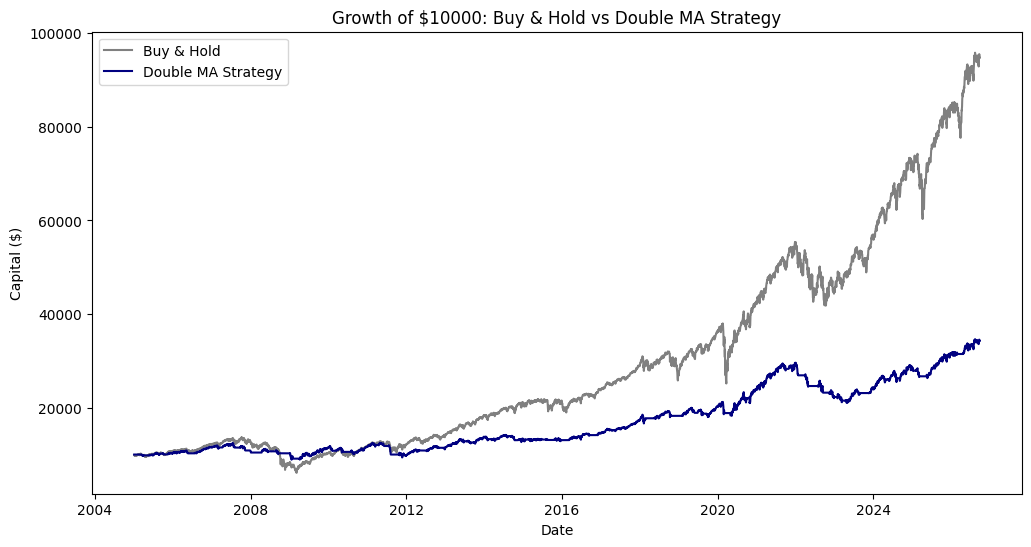

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
plt.plot(data.index, data['Market_Value'], label = "Buy & Hold", color = "grey")
plt.plot(data.index, data['Strategy_Value'], label = "Double MA Strategy", color = "navy")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.legend()
plt.title(f"Growth of ${capital}: Buy & Hold vs Double MA Strategy")
plt.show()

In [ ]:
cost_per_trade = 0.0005                                   # 5 bps
data['trade'] = data['position'].diff().abs()             # 1 when you enter or exit
data['strat_ret_net'] = data['strat_ret'] - data['trade'] * cost_per_trade

Equity Curve
Strategy: “If I followed my trading strategy, how would my money have grown over time?”

Benchmark: “What if I had just bought the asset at the beginning and never traded it?”

In [ ]:
data['equity'] = (1 + data['strat_ret_net']).cumprod()
data['equity_bh'] = (1 + data['ret']).cumprod()           # buy-and-hold benchmark

Sharpe ratio — return per unit of risk (volatility)
* Divide average return by its standard deviation (how bumpy the ride was)

In [ ]:
sharpe = data['strat_ret_net'].mean() / data['strat_ret_net'].std() * np.sqrt(252)

Max Drawdown: largest percentage drop an investment experiences from a peak value to a trough value before setting a new high.

In [ ]:
running_max = data['equity'].cummax()
drawdown = data['equity'] / running_max - 1
max_dd = drawdown.min()                                    # e.g. -0.35 = down 35%

CAGR (compound annual growth rate)

In [ ]:
years = len(data) / 252
cagr = data['equity'].iloc[-1] ** (1/years) - 1

Volatility

In [ ]:
data['volatility_20d'] = data['ret'].rolling(20).std()

Moving Average Ratio

In [ ]:
data['sma_ratio'] = data['sma_fast'] / data['sma_slow'] - 1

RSI (Relative Strength Index)

In [ ]:
delta = data['Adj Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data['rsi'] = 100 - (100 / (1 + rs))


Volume

In [ ]:
data['volume_ratio'] = (
    data['Volume'] /
    data['Volume'].rolling(20).mean()
)

In [ ]:
data['price_sma20'] = data['Adj Close'] / data['sma_fast'] - 1
data['price_sma50'] = data['Adj Close'] / data['sma_slow'] - 1

data['ret_5d'] = data['Adj Close'].pct_change(5, fill_method=None)
data['ret_20d'] = data['Adj Close'].pct_change(20, fill_method=None)


In [ ]:
data['target']= data['Adj Close'].shift(-5) / data['Adj Close'] - 1

In [ ]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,...,equity_bh,volatility_20d,sma_ratio,rsi,volume_ratio,price_sma20,price_sma50,ret_5d,ret_20d,target
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,80.973549,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999942
2005-01-04,79.984077,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,...,0.987780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000086
2005-01-05,79.432129,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,...,0.980964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999958
2005-01-06,79.835953,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,...,0.985951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000100
2005-01-07,79.721558,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,...,0.984538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.999934


Out of Sample Testing

In [ ]:
print(y.describe())

count    5412.000000
mean        0.002380
std         0.023947
min        -0.197933
25%        -0.008071
50%         0.004019
75%         0.014850
max         0.194036
Name: target, dtype: float64


In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# X: 20-day SMA = data['sma_fast']
# X: 50-day SMA = data['sma_slow']
# X: 20-day Volatility = data['volatility_20d']
# X: Relative Strength Index (RSI) = data['rsi']

# Y: Target = data['target']

x_col = ['volatility_20d','rsi', 'sma_ratio', 'price_sma20', 'price_sma50', 'ret_5d', 'ret_20d']
sub = data[x_col + ['target']].dropna()
X = sub[x_col]
y = sub['target']

H = 5

tscv = TimeSeriesSplit(n_splits=5, gap=H)
scores = []

for tr,va in tscv.split(X):
  cut = int(len(tr) - H)
  fit_idx = tr[:cut - H]
  es_idx = tr[cut:]

  X_fit, y_fit = X.iloc[fit_idx], y.iloc[fit_idx]
  X_es,  y_es  = X.iloc[es_idx],  y.iloc[es_idx]
  X_val, y_val = X.iloc[va],      y.iloc[va]
  model = xgb.XGBRegressor(
        objective='reg:pseudohubererror',  # 노이즈에 견고 (또는 reg:squarederror)
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,              # 트리 깊이 (level-wise)
        subsample=0.8,            # 행 샘플링
        colsample_bytree=0.8,     # 열 샘플링
        reg_alpha=0,            # L1 정규화
        reg_lambda=0.5,           # L2 정규화
        gamma=0,                # 분할 최소 손실감소
        tree_method='hist',       # 빠른 히스토그램 방식
        early_stopping_rounds=100,
        random_state=42,
  )
  model.fit(X_fit,y_fit,
            eval_set=[(X_es,y_es)],
            verbose=False)

  #-------- predict ------------
  pred = model.predict(X_val)
  scores.append(
      {
          'test_start' : X_val.index[0],
          'test_end' : X_val.index[-1],
          'IC': spearmanr(pred, y_val).correlation,
          'acc': (np.sign(pred) == np.sign(y_val)).mean(),
          'base': (y_val>0).mean(),
          'best_iter': model.best_iteration,
          'best_score': model.best_score,
          'rmse': mean_squared_error(y_val, pred, squared=False),
      }
  )

print(pd.DataFrame(scores).round(3))


[0]	validation_0-mphe:0.00054
[100]	validation_0-mphe:0.00108
[0]	validation_0-mphe:0.00015
[100]	validation_0-mphe:0.00015
[200]	validation_0-mphe:0.00015
[216]	validation_0-mphe:0.00015
[0]	validation_0-mphe:0.00015
[100]	validation_0-mphe:0.00015
[151]	validation_0-mphe:0.00015
[0]	validation_0-mphe:0.00044
[100]	validation_0-mphe:0.00044
[127]	validation_0-mphe:0.00044
[0]	validation_0-mphe:0.00019
[100]	validation_0-mphe:0.00019
[106]	validation_0-mphe:0.00019
  test_start   test_end     IC    acc   base  best_iter  best_score
0 2008-10-13 2012-05-10  0.068  0.419  0.583          0       0.001
1 2012-05-11 2015-12-10  0.015  0.569  0.612        116       0.000
2 2015-12-11 2019-07-15  0.092  0.618  0.627         51       0.000
3 2019-07-16 2023-02-10  0.032  0.595  0.603         27       0.000
4 2023-02-13 2026-09-17  0.055  0.615  0.619          6       0.000


In [ ]:
from scipy.stats import spearmanr

#pred = model.predict(X_val)

#direct_acc = (np.sign(pred) == np.sign(y_val)).mean()
#ic = spearmanr(pred, y_val).correlation

#print(f"방향 정확도: {direct_acc:.3f}")
#print(f"IC: {ic:.4f}")

방향 정확도: 1.000
IC: 0.0505


In [ ]:
data['target_class'] = (data['ret'].shift(-1) > 0).astype(int)
x_col = ['sma_fast','sma_slow','volatility_20d','rsi', 'volume_ratio']
sub_class = data[x_col + ['target_class']].dropna()
X_class = sub_class[x_col]
y_class = sub_class['target_class']

tscv = TimeSeriesSplit(n_splits=5, gap=5)
scores_class = [] # Using a new list for classification scores

for tr,va in tscv.split(X_class):
  X_train_class, X_val_class = X_class.iloc[tr], X_class.iloc[va]
  y_train_class, y_val_class = y_class.iloc[tr], y_class.iloc[va]

  model_class = xgb.XGBClassifier(  # Changed to XGBClassifier
        objective='binary:logistic',  # Objective for binary classification
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        gamma=0.1,
        tree_method='hist',
        early_stopping_rounds=100,
        eval_metric='logloss',  # Evaluation metric for classification
        random_state=42,
  )
  model_class.fit(X_train_class, y_train_class,
            eval_set=[(X_val_class, y_val_class)],
            verbose=100)
  scores_class.append(model_class.best_score)

[0]	validation_0-logloss:0.68788
[100]	validation_0-logloss:0.68990
[129]	validation_0-logloss:0.69265
[0]	validation_0-logloss:0.68705
[100]	validation_0-logloss:0.70523
[104]	validation_0-logloss:0.70709
[0]	validation_0-logloss:0.68686
[100]	validation_0-logloss:0.72143
[0]	validation_0-logloss:0.69082
[100]	validation_0-logloss:0.69331
[0]	validation_0-logloss:0.68600
[100]	validation_0-logloss:0.70423


Step 10: Plot equity vs equity_bh

```
data['ret']
data['sma_fast']
data['sma_slow']
data['ema_fast']
data['ema_slow']

20-day SMA       ─┐
50-day SMA        │
20-day EMA        │
50-day EMA        ├──→ ML model (Regression) ──→ UP / DOWN
5-day return      │
20-day volatility │
RSI               │
volume           ─┘

Date	SMA fast	SMA slow	EMA fast	EMA slow	Return
Day 1	100	98	101	99	0.01
Day 2	101	99	102	100	-0.02
Day 3	99	100	100	101	0.03


"Based on these clues, will SPY be up over the next 5 days?"
Target Value
If yes (value >0): 1
If no (value < 0): 0

Compare double moving average vs. benchmark vs ml`
````